In [1]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import cm
from matplotlib import patches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import mplhep as hep
import os
from tqdm import tqdm
import ipywidgets as widget
import xsec
import itertools
from sklearn import metrics

Welcome to JupyROOT 6.30/04


In [ ]:
ROOT.gInterpreter.Declare("""
float compute_weight( float norm, float triggerXSF, float triggerSF, float pileupWeight, float pileupJetIDWeight, float lepIdSF, float isoSF, float L1NonPrefiringProb_CommonCalc, float MCWeight_MultiLepCalc, float tthfWeight, float btagDeepJetWeight, float btagDeepJet2DWeight_HTnj ){
    return norm * triggerSF * pileupWeight * pileupJetIDWeight * lepIdSF * isoSF * L1NonPrefiringProb_CommonCalc * ( MCWeight_MultiLepCalc / abs( MCWeight_MultiLepCalc ) ) * tthfWeight * btagDeepJetWeight * btagDeepJet2DWeight_HTnj;
}
""")

In [ ]:
ROOT.gInterpreter.Declare("""
float compute_weight_ttbar( float norm, float triggerXSF, float triggerSF, float pileupWeight, float pileupJetIDWeight, float topPtWeight13TeV, float lepIdSF, float isoSF, float L1NonPrefiringProb_CommonCalc, float MCWeight_MultiLepCalc, float tthfWeight, float btagDeepJetWeight, float btagDeepJet2DWeight_HTnj ){
    return norm * triggerSF * pileupWeight * pileupJetIDWeight * topPtWeight13TeV * lepIdSF * isoSF * L1NonPrefiringProb_CommonCalc * ( MCWeight_MultiLepCalc / abs( MCWeight_MultiLepCalc ) ) * tthfWeight * btagDeepJetWeight * btagDeepJet2DWeight_HTnj;
}
""")

In [ ]:
era = "2017"
#rPath = "root://brux30.hep.brown.edu:1094//store/user/dali/"
rPath = "root://cmseos.fnal.gov//store/user/dsunyou/"
rDir = rPath + "FWLJMET106XUL_singleLep{}UL_RunIISummer20_3t_step3/nominal/".format( era )
nTree = "ljmet"
fGroups = {
    "ST": [
        "ST_s-channel_4f_leptonDecays_TuneCP5_13TeV-amcatnlo-pythia8_hadd.root",
        "ST_t-channel_top_4f_InclusiveDecays_TuneCP5_13TeV-powheg-madspin-pythia8_hadd.root",
        "ST_t-channel_antitop_4f_InclusiveDecays_TuneCP5_13TeV-powheg-madspin-pythia8_hadd.root",
        "ST_tW_top_5f_inclusiveDecays_TuneCP5_13TeV-powheg-pythia8_hadd.root",
        "ST_tW_antitop_5f_inclusiveDecays_TuneCP5_13TeV-powheg-pythia8_hadd.root",
    ],
    "TTBAR": [
        "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8_tt1b_hadd.root",
        "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8_tt2b_hadd.root",
        "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8_ttbb_hadd.root",
        "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8_ttcc_hadd.root",
        "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8_ttjj_hadd.root",
        "TTToHadronic_TuneCP5_13TeV-powheg-pythia8_tt1b_hadd.root",
        "TTToHadronic_TuneCP5_13TeV-powheg-pythia8_tt2b_hadd.root",
        "TTToHadronic_TuneCP5_13TeV-powheg-pythia8_ttbb_hadd.root",
        "TTToHadronic_TuneCP5_13TeV-powheg-pythia8_ttcc_hadd.root",
        "TTToHadronic_TuneCP5_13TeV-powheg-pythia8_ttjj_hadd.root",
        "TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_tt1b_hadd.root",
        "TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_tt2b_hadd.root",
        "TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_ttbb_hadd.root",
        "TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_ttcc_hadd.root",
        "TTToSemiLepton_HT500Njet9_TuneCP5_13TeV-powheg-pythia8_ttjj_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_tt1b_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_tt2b_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttbb_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttcc_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_1_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_2_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_3_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_4_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_5_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_6_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_7_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_8_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_9_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT0Njet0_ttjj_10_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_tt1b_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_tt2b_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_ttbb_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_ttcc_hadd.root",
        "TTToSemiLeptonic_TuneCP5_13TeV-powheg-pythia8_HT500Njet9_ttjj_hadd.root",
    ],
    "TTTW": [
        "TTTW_TuneCP5_13TeV-madgraph-pythia8_hadd.root"
    ],
    "TTTJ": [
        "TTTJ_TuneCP5_13TeV-madgraph-pythia8_hadd.root"
    ],
    "TTTT": [
        "TTTT_TuneCP5_13TeV-amcatnlo-pythia8_hadd.root",   
        #"TTTT_TuneCP5_13TeV-amcatnlo-pythia8_2_hadd.root",
        #"TTTT_TuneCP5_13TeV-amcatnlo-pythia8_3_hadd.root",
    ],
    "TTH": [
        "ttHTobb_M125_TuneCP5_13TeV-powheg-pythia8_hadd.root",
        "ttHToNonbb_M125_TuneCP5_13TeV-powheg-pythia8_hadd.root",
    ]
}

In [ ]:
rFile = ROOT.TFile.Open( rDir + "TTTo2L2Nu_TuneCP5_13TeV-powheg-pythia8_tt1b_hadd.root" )
rTree = rFile.Get( "ljmet" )
rBranches = [ branch.GetName() for branch in rTree.GetListOfBranches() ]
branchNames = widget.Dropdown( options = rBranches )
branchNames

In [6]:
fBase = "DataPastTriggerX == 1 && MCPastTriggerX == 1 && minDR_lepJet > 0.2 && AK4HT > 390 && ( corr_met_MultiLepCalc + 0.667 * MT_lepMet ) > 70."
variables = [
    "NJets_JetSubCalc",
    "NJetsCSV_JetSubCalc",
    "NresolvedTops1pFake",
    "DNN_1to40_nJ4pnB1p",
    #"DNN_1to40_2v4T_nJ4pnB1p",
    #"DNN_1to40_3v4T_nJ6pnB2p",
    #"DNN_1to40_Run2_3v4T_nJ6pnB2p",
    #"DNN_1to40_Run2_3vALL_nJ4pnB1p",
    "DNN_1to40_Run2_nJ4pnB1p"
]
rDF = { group: {} for group in fGroups }


for g in fGroups:
    print( "Loading group: " + g )
    for f in tqdm( fGroups[g] ):
        if g == "TTBAR":
            rDF_ = ROOT.RDataFrame( nTree, rDir + f ).Filter( fBase ).Define( "weight", "compute_weight_ttbar( {}, triggerXSF, triggerSF, pileupWeight, pileupJetIDWeight, topPtWeight13TeV, lepIdSF, isoSF, L1NonPrefiringProb_CommonCalc, MCWeight_MultiLepCalc, tthfWeight, btagDeepJetWeight, btagDeepJet2DWeight_HTnj )".format( xsec.norm[f] ) )
            rDF[g][f] = rDF_.AsNumpy( columns = variables + [ "weight" ] )
        else:
            rDF_ = ROOT.RDataFrame( nTree, rDir + f ).Filter( fBase ).Define( "weight", "compute_weight( {}, triggerXSF, triggerSF, pileupWeight, pileupJetIDWeight, lepIdSF, isoSF, L1NonPrefiringProb_CommonCalc, MCWeight_MultiLepCalc, tthfWeight, btagDeepJetWeight, btagDeepJet2DWeight_HTnj )".format( xsec.norm[f] ) )
            rDF[g][f] = rDF_.AsNumpy( columns = variables + [ "weight" ] )

Loading group: ST


100%|██████████| 5/5 [00:25<00:00,  5.12s/it]


Loading group: TTBAR


100%|██████████| 34/34 [04:35<00:00,  8.10s/it]


Loading group: TTTW


...

100%|██████████| 1/1 [00:02<00:00,  2.74s/it]


Loading group: TTTT


100%|██████████| 3/3 [00:59<00:00, 19.78s/it]


Loading group: TTH


100%|██████████| 2/2 [00:15<00:00,  7.73s/it]


In [7]:
variable = widget.Dropdown( options = variables )
variable

Dropdown(options=('NJets_JetSubCalc', 'NJetsCSV_JetSubCalc', 'NresolvedTops1pFake', 'DNN_1to40_nJ4pnB1p', 'DNN…

In [20]:
cut_NJ = 6
cut_NB = 2
cut_NHOT = 0
mask = { group: {} for group in fGroups }
for g in fGroups:
    for f in fGroups[g]:
        mask[g][f] = ( rDF[g][f]["NJets_JetSubCalc"] >= cut_NJ ) \
            & ( rDF[g][f]["NJetsCSV_JetSubCalc"] >= cut_NB ) \
            & ( rDF[g][f]["NresolvedTops1pFake"] >= cut_NHOT ) \
            #& ( rDF[g][f]["DNN_1to20_3v4T_nJ6pnB2p"] > 0. )

In [21]:
combined = { group: np.array([]) for group in fGroups }
weights = { group: np.array([]) for group in fGroups }
for g in fGroups:
    print( "Combining files in group: " + g )
    for f in tqdm( fGroups[g] ):
        combined[g] = np.concatenate( [ combined[g], rDF[g][f][variable.value][ mask[g][f] ] ] )
        weights[g] = np.concatenate( [ weights[g], rDF[g][f]["weight"][ mask[g][f] ] ] )

Combining files in group: ST


100%|██████████| 5/5 [00:00<00:00, 1037.06it/s]


Combining files in group: TTBAR


100%|██████████| 34/34 [00:00<00:00, 62.64it/s] 


Combining files in group: TTTW


...

100%|██████████| 1/1 [00:00<00:00, 512.19it/s]


Combining files in group: TTTT


100%|██████████| 3/3 [00:00<00:00, 21.83it/s]


Combining files in group: TTH


100%|██████████| 2/2 [00:00<00:00, 98.02it/s]


In [22]:
bins = np.linspace( 0, 1, 31 )
hists = {}
hists_norm = {}
for g in fGroups:
    hists_norm[g] = np.histogram( combined[g], weights = weights[g], bins = bins, density = True )
    hists[g] = np.histogram( combined[g], weights = weights[g], bins = bins, density = False )

In [13]:
groupsPlot = widget.SelectMultiple( options = fGroups.keys() )
groupsPlot

SelectMultiple(options=('ST', 'TTBAR', 'TTTW', 'TTTJ', 'TTTT', 'TTH'), value=())

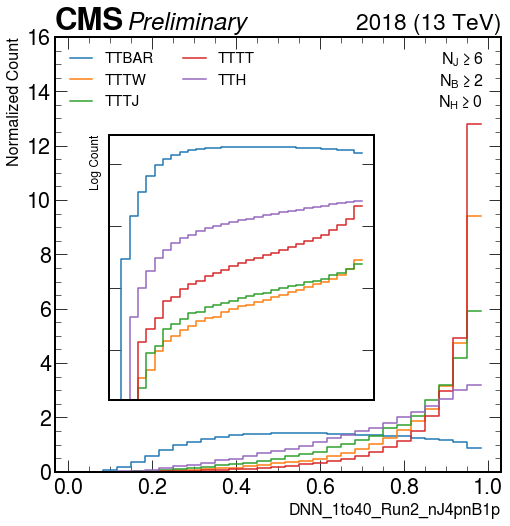

In [25]:
plt.style.use( hep.style.CMS )
fig, ax = plt.subplots( figsize = (8,8) )
hep.cms.text( "Work in Progress", fontsize = 24 )
hep.cms.lumitext( "{} (13 TeV)".format( era ), fontsize = 24 )
for g in groupsPlot.value:
    plt.step( 0.5 * ( hists_norm[g][1][1:] + hists_norm[g][1][:-1] ), hists_norm[g][0], where = "pre", label = "{}".format( g ) )
sub_ax = fig.add_axes( [0.22,0.25,0.46,0.46], fc = "white" )
for g in groupsPlot.value:
    sub_ax.step( 0.5 * ( hists[g][1][1:] + hists[g][1][:-1] ), hists[g][0], where = "pre" )
sub_ax.set_ylabel( "Log Count", fontsize = 12 )
sub_ax.set_yscale( "log" )
sub_ax.set_yticklabels([])
sub_ax.set_xticks([])
ax.set_ylim( 0, 16 )
ax.legend( loc = "upper left", ncol = 2, fontsize = 15 )
ax.set_ylabel( "Normalized Count", fontsize = 16 )
ax.set_xlabel( variable.value, fontsize = 16 )
ax.set_yscale( "linear" )
ax.annotate( r"$N_J\geq{}$".format( cut_NJ ), (0.96,0.97), xycoords = "axes fraction", ha = "right", va = "top", fontsize = 16 )
ax.annotate( r"$N_B\geq{}$".format( cut_NB ), (0.96,0.92), xycoords = "axes fraction", ha = "right", va = "top", fontsize = 16 )
ax.annotate( r"$N_H\geq{}$".format( cut_NHOT ), (0.96,0.87), xycoords = "axes fraction", ha = "right", va = "top", fontsize = 16 )
plt.show()

Plot ROC curve comparing any group to three top

In [26]:
variable_auc = widget.Dropdown( options = [ var for var in variables if "DNN" in var ] )
variable_auc

Dropdown(options=('DNN_1to40_nJ4pnB1p', 'DNN_1to40_Run2_nJ4pnB1p'), value='DNN_1to40_nJ4pnB1p')

In [27]:
groups_roc = widget.SelectMultiple( options = [ group for group in fGroups.keys() if group not in [ "TTTW", "TTTJ" ] ] )
groups_roc                 

SelectMultiple(options=('ST', 'TTBAR', 'TTTT', 'TTH'), value=())

In [40]:
truth = { group: np.array([]) for group in fGroups }
for g in fGroups:
    for f in fGroups[g]:
        if g in [ "TTTW", "TTTJ" ]:
            truth[g] = np.concatenate( [ truth[g], np.ones(len(rDF[g][f][variable_auc.value][mask[g][f]])) ] )
        else:
            truth[g] = np.concatenate( [ truth[g], np.zeros(len(rDF[g][f][variable_auc.value][mask[g][f]])) ] )

In [41]:
combined = { group: np.array([]) for group in fGroups }
weights = { group: np.array([]) for group in fGroups }
for g in fGroups:
    print( "Combining files in group: " + g )
    for f in tqdm( fGroups[g] ):
        combined[g] = np.concatenate( [combined[g],rDF[g][f][variable_auc.value][mask[g][f]]] )
        weights[g] = np.concatenate( [weights[g],rDF[g][f]["weight"][mask[g][f]]] )

Combining files in group: ST


100%|██████████| 5/5 [00:00<00:00, 1499.79it/s]


Combining files in group: TTBAR


100%|██████████| 34/34 [00:00<00:00, 78.54it/s] 


Combining files in group: TTTW


...

100%|██████████| 1/1 [00:00<00:00, 581.17it/s]


Combining files in group: TTTT


100%|██████████| 3/3 [00:00<00:00, 26.56it/s]


Combining files in group: TTH


100%|██████████| 2/2 [00:00<00:00, 117.64it/s]


In [42]:
truth_roc = {}
y_roc = {}
weight_roc = {}
for g in groups_roc.value:
    truth_roc[g] = np.concatenate( [ truth["TTTW"], truth["TTTJ"], truth[g] ] )
    y_roc[g] = np.concatenate( [ combined["TTTW"], combined["TTTJ"], combined[g] ] )
    weight_roc[g] = np.concatenate( [ weights["TTTW"], weights["TTTJ"], weights[g] ] )

In [43]:
fpr = {}
tpr = {}
thresholds = {}
AUC = {}
for g in groups_roc.value:
    fpr[g], tpr[g], thresholds[g] = metrics.roc_curve( truth_roc[g], y_roc[g], sample_weight = weight_roc[g] )
    AUC[g] = metrics.auc( tpr[g], fpr[g] )

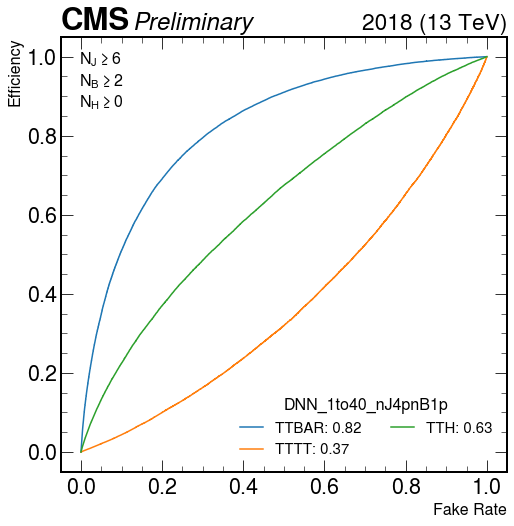

In [44]:
plt.style.use( hep.style.CMS )
plt.figure( figsize = (8,8) )
hep.cms.text( "Work in Progress", fontsize = 24 )
hep.cms.lumitext( "{} (13 TeV)".format( era ), fontsize = 24 )
for g in groups_roc.value:
    plt.plot( fpr[g], tpr[g], label = "{}: {:.2f}".format( g, 1. - AUC[g] ) )
plt.legend( loc = "lower right", title = variable_auc.value, ncol = 2, fontsize = 15, title_fontsize = 16 )
plt.ylabel( "Efficiency", fontsize = 16 )
plt.xlabel( "Fake Rate", fontsize = 16 )
plt.yscale( "linear" )
plt.annotate( r"$N_J\geq{}$".format( cut_NJ ), (0.04,0.97), xycoords = "axes fraction", ha = "left", va = "top", fontsize = 16 )
plt.annotate( r"$N_B\geq{}$".format( cut_NB ), (0.04,0.92), xycoords = "axes fraction", ha = "left", va = "top", fontsize = 16 )
plt.annotate( r"$N_H\geq{}$".format( cut_NHOT ), (0.04,0.87), xycoords = "axes fraction", ha = "left", va = "top", fontsize = 16 )
plt.show()